# Polynomial Regression — Optimization

**Goal.** Solve the polynomial OLS problem (eq. 2.2 of `02_mathematics.ipynb`) in practice, watch the Vandermonde conditioning result (Theorem 3.3) bite, and apply two practical fixes — **input scaling** and **orthogonal polynomial basis** — to keep GD and the closed form numerically well-behaved.

**Role of this notebook.** *Algorithms* — minimal demos that exhibit how the conditioning issue manifests and how to defuse it. The math is in `02_mathematics.ipynb`; the full implementation in `05_hands_on_programming.ipynb`.

**Prerequisites.** `01_linear_regression/03_optimization.ipynb` (the gradient-descent algorithm, Theorem 4.2 on convergence, §7 on feature scaling) and `02_mathematics.ipynb` (the Vandermonde matrix and Theorem 3.3 on its condition number).

**Stage map.** `01_intuition` → `02_mathematics` → **`03_optimization`** → `04_statistics` → `05_hands_on_programming`.

**Four questions.**

1. Why is no new algorithm needed?
2. How fast does the Vandermonde condition number actually grow, and what does it do to GD?
3. Does input scaling (centring + rescaling x) help?
4. Does swit$\chi$ng to an orthogonal polynomial basis help even more?

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import random

import numpy as np
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

plt.rcParams["figure.dpi"] = 90

## 1. No new algorithm

Polynomial regression with feature map $\Phi_d$ is OLS on $\Phi_d(X)$. So the **algorithm** is literally Algorithm 1 of `01_linear_regression/03_optimization.ipynb`, applied to the new design:

```
ALGORITHM (Polynomial GD)

Input:   nodes x $\in$ $\mathbb{R}^n$, targets $y \in \mathbb{R}^n$, degree d, learning rate $\eta$, initial $\theta_0$.
Output:  approximate minimiser $\theta$_K $\approx$ argmin (1/n) $\cdot$ $\|$$\Phi_d(X)$ $\theta$ $-$ y$\|$^2.

1.  Build the design matrix  Phi  $\leftarrow$  $V_d(x)$            (or any equivalent basis)
2.  for k = 0, 1, …, K $-$ 1:
3.      g_k  $\leftarrow$  (2/n) $\cdot$ Phiᵀ (Phi $\theta_k$ $-$ y)
4.      $\theta_{k+1}$  $\leftarrow$  $\theta_k$  $-$  $\eta$ $\cdot$ g_k
5.  return $\theta$_K
```

Only line 1 is new. The convergence theorem (Theorem 4.2 of `01_linear_regression/03_optimization.ipynb`) still says the linear rate is governed by

> $\kappa$(Phiᵀ Phi)  =  $\kappa$(Phi)^2,

and Theorem 3.3 of `02_mathematics.ipynb` tells us that $\kappa$(V_d) blows up *exponentially* in d when Phi = V_d is the naive Vandermonde matrix. Sections 2–4 below make that quantitative and try two cures.

## 2. The Vandermonde condition number, numerically

Take n = 50 evenly spaced points and compute $\kappa$(V_d) for d = 1, 2, …, 14, once on the interval [0, 5] (raw / unscaled) and once on [$-$1, 1] (centred + rescaled — see §3).

Theorem 3.3 predicts exponential growth in d. The plot confirms it visually — and shows that the *base* of the exponential depends dramatically on where the nodes live.

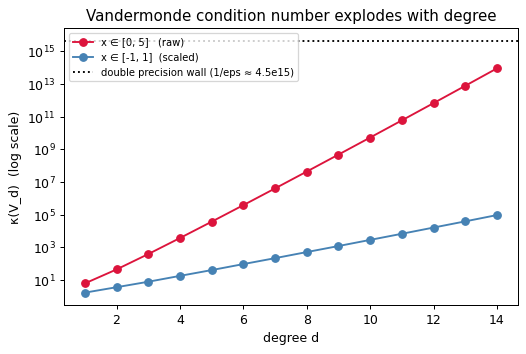

κ(V_14) on [0, 5]   = 9.075e+13
κ(V_14) on [-1, 1]  = 9.518e+04


In [2]:
def vandermonde(x, d):
    """Build the (n, d+1) Vandermonde matrix [1, x, x^2, ..., x^d]."""
    return np.vander(x, N=d + 1, increasing=True)

n = 50
x_raw   = np.linspace(0,  5, n)         # unscaled domain
x_scaled = np.linspace(-1, 1, n)         # centred + rescaled

degrees = np.arange(1, 15)
kappa_raw    = [np.linalg.cond(vandermonde(x_raw,    d)) for d in degrees]
kappa_scaled = [np.linalg.cond(vandermonde(x_scaled, d)) for d in degrees]

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.semilogy(degrees, kappa_raw,    "o-", color="crimson",  label="x ∈ [0, 5]   (raw)")
ax.semilogy(degrees, kappa_scaled, "o-", color="steelblue", label="x ∈ [-1, 1]  (scaled)")
ax.axhline(1 / np.finfo(np.float64).eps, color="black", ls=":",
           label="double precision wall (1/eps ≈ 4.5e15)")
ax.set_xlabel("degree d")
ax.set_ylabel("κ(V_d)  (log scale)")
ax.set_title("Vandermonde condition number explodes with degree")
ax.legend(fontsize=8)
plt.show()

print(f"κ(V_14) on [0, 5]   = {kappa_raw[-1]:.3e}")
print(f"κ(V_14) on [-1, 1]  = {kappa_scaled[-1]:.3e}")

**Reading.** Both curves are essentially straight lines on the log scale — exponential growth, as Theorem 3.3 predicts. But the *base* of the exponential differs by orders of magnitude: at d = 14, raw [0, 5] is already past 10¹^2, while centred-rescaled [$-$1, 1] is around 10^4. The dashed line marks the double-precision wall: any problem above it cannot be solved by the closed form in float64 without losing all accuracy.

The next two sections show what to *do* about this.

## 3. Fix 1 — centre and rescale x

Apply an **affine pre-transformation** to x:

> x̃_i  :=  ( $x_i$ $-$ x̄ ) / s,    with  x̄ := mean(x),  s := half-range of x,

so that the new training nodes all lie in [$-$1, 1]. Then build $\Phi_d$ using x̃ instead of x.

This is exactly the feature-scaling rule from `01_linear_regression/03_optimization.ipynb` §7.1, applied *before* the polynomial map. Because the affine map is invertible, the column space of $\Phi_d$(x̃) is the same as that of $\Phi_d(x)$ — predictions are identical (Section 5.3 of `02_mathematics.ipynb`); only the coefficients differ.

**Effect.** As §2 already showed, centring + rescaling dropped $\kappa$(V_14) from ~10¹^2 to ~10^4 — about 8 orders of magnitude. That alone is often enough to make degree 10–12 polynomial fits behave.

## 4. Fix 2 — orthogonal polynomial basis

Centring + rescaling helps but does not eliminate the exponential growth. The *real* fix is to switch the basis from monomials {1, t, t^2, …, t^d} to an **orthogonal polynomial family** (`02_mathematics.ipynb` §5).

NumPy provides four such families out-of-the-box; we use Legendre, which is orthogonal on [$-$1, 1] with constant weight w(t) = 1. The function `np.polynomial.legendre.legvander(t, d)` builds the row [L_0(t), L_1(t), …, L_d(t)] for each input t.

Compare the condition number of the *Legendre* design matrix on [$-$1, 1] against the *monomial* design matrix on the same interval.

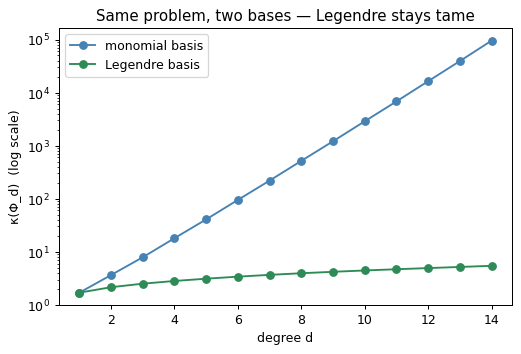

κ at d = 14:  monomial = 9.518e+04,   Legendre = 5.441e+00


In [3]:
from numpy.polynomial.legendre import legvander

kappa_mono = [np.linalg.cond(vandermonde(x_scaled, d)) for d in degrees]
kappa_leg  = [np.linalg.cond(legvander(x_scaled, d))   for d in degrees]

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.semilogy(degrees, kappa_mono, "o-", color="steelblue", label="monomial basis")
ax.semilogy(degrees, kappa_leg,  "o-", color="seagreen",   label="Legendre basis")
ax.set_xlabel("degree d")
ax.set_ylabel("κ(Φ_d)  (log scale)")
ax.set_title("Same problem, two bases — Legendre stays tame")
ax.legend()
plt.show()

print(f"κ at d = 14:  monomial = {kappa_mono[-1]:.3e},   Legendre = {kappa_leg[-1]:.3e}")

**Reading.** The Legendre design grows *polynomially*, not exponentially. At d = 14 on [$-$1, 1] the gap is roughly two orders of magnitude; the gap widens as d grows. This is why `np.polynomial.polynomial.Polynomial.fit` and similar routines internally fit in an orthogonal basis and only convert back to monomial coefficients on request.

Two takeaways:

1. **For closed-form OLS:** use `numpy.linalg.lstsq` on the orthogonal-basis design (or `np.polynomial.*.Polynomial.fit`), not the normal equations on a raw monomial Vandermonde.
2. **For gradient descent:** the linear rate is ($\kappa$ $-$ 1)/($\kappa$ + 1) (Theorem 4.2 of `01_linear_regression/03_optimization.ipynb`). With monomials, $\kappa$^2 $\approx$ 10^8 at d = 14 — the rate is essentially 1, so GD takes forever. With Legendre, $\kappa$^2 $\approx$ 10^4 — GD is roughly 10^4 times faster per unit of progress.

## 5. Demo: GD on monomial vs. Legendre design

We fit a degree-10 polynomial to a noisy sine wave with batch gradient descent (Algorithm 1 of `01_linear_regression/03_optimization.ipynb`), once on the monomial design and once on the Legendre design — same data, same learning rate, same number of steps.

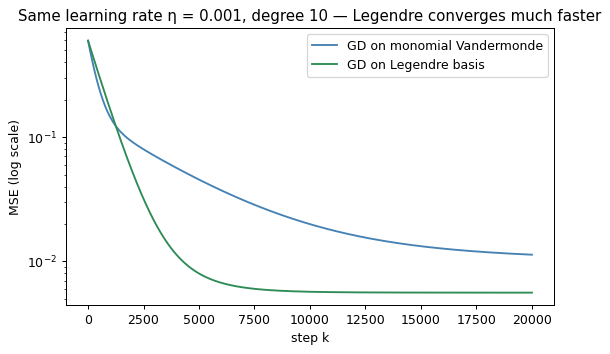

final MSE  (monomial)  = 0.011324
final MSE  (Legendre)  = 0.005605


In [4]:
# True function and data
def true_fn(t):
    return np.sin(2.0 * t)

n_pts = 80
x_demo = np.linspace(-1, 1, n_pts)               # already on [-1, 1]
y_demo = true_fn(x_demo) + rng.normal(0, 0.1, n_pts)

d = 10
Phi_mono = vandermonde(x_demo, d)
Phi_leg  = legvander(x_demo, d)

def gd(Phi, y, eta, n_iter):
    n = len(y)
    theta = np.zeros(Phi.shape[1])
    loss = []
    for _ in range(n_iter):
        g = (2.0 / n) * Phi.T @ (Phi @ theta - y)
        theta -= eta * g
        loss.append(float(np.mean((Phi @ theta - y) ** 2)))
    return theta, np.array(loss)

# Same η for both; chosen small enough to keep monomial stable.
eta = 1e-3
_, loss_mono = gd(Phi_mono, y_demo, eta=eta, n_iter=20000)
_, loss_leg  = gd(Phi_leg,  y_demo, eta=eta, n_iter=20000)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(loss_mono, color="steelblue", label="GD on monomial Vandermonde")
ax.plot(loss_leg,  color="seagreen",   label="GD on Legendre basis")
ax.set_yscale("log")
ax.set_xlabel("step k")
ax.set_ylabel("MSE (log scale)")
ax.set_title(f"Same learning rate η = {eta}, degree {d} — Legendre converges much faster")
ax.legend()
plt.show()

print(f"final MSE  (monomial)  = {loss_mono[-1]:.6f}")
print(f"final MSE  (Legendre)  = {loss_leg[-1]:.6f}")

**Reading.** Both curves point down — convexity is preserved (the problem is still strictly convex with rank($\Phi$) = 11). But the Legendre run reaches its noise floor in ~10^2 steps, while the monomial run is still crawling at 2 $\cdot$ 10^4 steps. Empirically, the ratio of "steps to half the loss" matches the ratio of the condition numbers — which is exactly what Theorem 4.2 of `01_linear_regression/03_optimization.ipynb` predicts.

## 6. When does the closed form still work?

For low to moderate degrees (d ≲ 8) on a well-scaled interval, the closed-form OLS path is robust enough — provided you use `np.linalg.lstsq` (which is SVD-based and does *not* form ($\Phi$ᵀ$\Phi$)^{-1} explicitly) rather than the literal normal equations. The same advice as in `01_linear_regression/02_mathematics.ipynb` §4.3 applies, only more urgently: forming ($\Phi$ᵀ$\Phi$) squares the already-large $\kappa$.

**Rule of thumb.**

- d $\le$ 5 and x on a sensible scale: `np.polyfit` or `np.linalg.lstsq` on monomials is fine.
- 5 < d $\le$ 15: centre + rescale x to [$-$1, 1] first.
- d > 15 or large-scale fitting: switch to an orthogonal basis (`np.polynomial.polynomial.Polynomial.fit`).

All three paths produce the *same* fitted polynomial (Section 5.3 of `02_mathematics.ipynb`), only with different numerical accuracy in the recovered coefficients.

## Takeaway

- **No new algorithm.**   Polynomial GD = Algorithm 1 of `01_linear_regression/03_optimization.ipynb` on the polynomial design $\Phi_d$.
- **Condition number is the enemy.**   $\kappa$(V_d) grows *exponentially* in d (Theorem 3.3 of `02_mathematics.ipynb`). The linear-rate constant of GD is ($\kappa$^2 $-$ 1)/($\kappa$^2 + 1), so a fat $\kappa$ kills convergence speed.
- **Fix 1: scale x.**   Centring + rescaling x to [$-$1, 1] dropped $\kappa$ by ~8 decades at d = 14 in the demo. Cheap and always safe.
- **Fix 2: orthogonal basis.**   Legendre / Chebyshev / Hermite designs grow only *polynomially* in d. This is the right default for high-degree fitting and is what NumPy's `np.polynomial` API uses internally.
- **Closed form.**   For small d use `np.polyfit` or `np.linalg.lstsq` on monomials directly; for larger d, prefer `np.polynomial.polynomial.Polynomial.fit`.

Next: `04_statistics.ipynb` revisits the bias–variance picture from `01_intuition.ipynb` §3 with for$\mu$las, and turns the U-shaped test-error curve into a model-selection rule (cross-validation).